# 5.0 SASCA — 신뢰 전파로 정보 합치기 · Normal ∥ Masked

## 이 노트북이 답하는 질문

4.x 는 중간값 하나(1라운드 SBox 출력)의 확률만 썼다. 실제 암호 연산에는 서로 얽힌 중간값이
수없이 많다. **그 정보를 전부 모으면 더 적은 파형으로 키가 나오는가?**

SASCA(Soft Analytical Side-Channel Attack)는 암호 알고리즘을 **인자 그래프**로 적고,
각 중간값에 프로파일링으로 얻은 확률을 붙인 뒤 **신뢰 전파**(belief propagation)로
정보를 퍼뜨린다. 그래프의 제약이 서로를 좁혀 준다.

| | |
|---|---|
| 학습 | 타겟별 `/profiling` (동일 예산) |
| 공격 | 타겟별 `/attack` 소수 장 |
| 하드웨어 | 불필요. `1.0.SNR`·4.0 개념 선행 |

여기서는 가장 작은 그래프를 쓴다 — 평문 $p$, 키 $k$, 그리고 $x = k \oplus p$, $y = \mathrm{SBOX}[x]$.
이 그래프만으로도 "확률을 어떻게 붙이고 어떻게 전파하는가" 를 전부 보여 준다.

---
## 1. 그래프 기술 문법

`FactorGraph` 는 문자열로 그래프를 받는다. 문법이 까다로워 자주 틀리므로 규칙을 적어 둔다.

```text
NC 256                    # 모든 변수의 클래스 수
TABLE sbox                # 룩업 테이블 선언 (값은 생성자 인자로 준다)
VAR SINGLE k              # 모든 트레이스에 공통인 변수 (키)
PUB MULTI p               # 트레이스마다 다르고 **공개**인 값 (평문)
VAR MULTI x               # 트레이스마다 다른 비밀 변수
VAR MULTI y
PROPERTY x = k ^ p        # 제약: XOR
PROPERTY y = sbox[x]      # 제약: 테이블 조회
```

| 키워드 | 뜻 |
|--------|-----|
| `VAR SINGLE` | 트레이스 전체에 하나 (키 바이트) |
| `VAR MULTI` | 트레이스마다 하나 (중간값) |
| `PUB MULTI` | 트레이스마다 하나이며 값이 알려짐 (평문) |
| `TABLE` | `FactorGraph(desc, {"sbox": ...})` 로 실제 배열을 넘긴다 |

| 단계 | 코드 |
|:----:|------|
| 그래프 | `fg = FactorGraph(GRAPH, {"sbox": SBOX.astype(np.uint32)})` |
| 상태 | `bp = BPState(fg, n_traces, {"p": plaintext.astype(np.uint32)})` |
| 증거 | `bp.set_evidence("y", proba)` — `(n, nc)` `float64`, **행마다 합이 1** |
| 전파 | `bp.bp_loopy(it=5, initialize_states=True)` |
| 결과 | `bp.get_distribution("k")` → `(nc,)` |

> **함정 셋**
> 1. 테이블 값은 **`uint32`** 여야 한다.
> 2. `PUB` 값도 **`uint32`** 다.
> 3. `set_evidence` 에 넣는 확률은 **정규화**해야 한다. LDA 의 `predict_proba` 출력이
>    행마다 정확히 1 이 아닐 수 있으므로 직접 나눈다.
> 4. `bp_loopy(..., initialize_states=True)` 를 빠뜨리면 이전 상태가 섞인다.

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.family"] = "NanumGothic"
matplotlib.rcParams["axes.unicode_minus"] = False

from scalib_common import (
    TARGETS, TARGET_IDS, SBOX, AES_BLOCK, sbox_out,
    load_group, load_poi, group_len, dataset_summary, require_target,
)
from scalib.modeling import LDAClassifier
from scalib.attacks import FactorGraph, BPState

BYTE = 0
P_DIM = 3
N_ATK = 30

GRAPH = """
NC 256
TABLE sbox
VAR SINGLE k
PUB MULTI p
VAR MULTI x
VAR MULTI y
PROPERTY x = k ^ p
PROPERTY y = sbox[x]
"""

AVAILABLE = {tid: group_len("profiling", tid) for tid in TARGET_IDS
             if require_target(tid)["dataset"].is_file()}
N_PROF = min(AVAILABLE.values())
print("프로파일링 보유:", {TARGETS[t]["short"]: n for t, n in AVAILABLE.items()})
print("→ 양쪽 모두 %d 장으로 맞춘다." % N_PROF)

sets = {}
for tid in AVAILABLE:
    z = load_poi(tid)
    w = z["poi_windows"].astype(int)
    cols = np.unique(w.ravel())
    prof = load_group("profiling", target=tid, n=N_PROF, samples=cols)
    atk = load_group("attack", target=tid, n=500, samples=cols)
    sets[tid] = (prof, atk, np.searchsorted(cols, w[BYTE]))

TRUE_KEY = np.array(sets[list(sets)[0]][1]["attrs"]["fixed_key"], dtype=np.uint8)
print("정답 키 바이트%d = 0x%02x" % (BYTE, TRUE_KEY[BYTE]))

프로파일링 보유: {'Normal': 100000, 'Masked': 100000}
→ 양쪽 모두 100000 장으로 맞춘다.


정답 키 바이트0 = 0x2f


---
## 2. 증거 만들기 — 4.0 과 같은 LDA

SASCA 는 확률을 **소비**할 뿐 스스로 만들지 않는다. 증거는 4.0 에서 쓴 LDA 가 그대로 준다.

In [2]:
proba_map = {}
for tid in sets:
    prof, atk, loc = sets[tid]
    y = sbox_out(prof["p"][:, BYTE], prof["k"][:, BYTE]).astype(np.uint16)
    lda = LDAClassifier(nc=256, p=P_DIM)
    lda.fit_u(np.ascontiguousarray(prof["t"][:, loc]), y)
    lda.solve()
    pr = lda.predict_proba(np.ascontiguousarray(atk["t"][:, loc]))
    pr = pr / pr.sum(axis=1, keepdims=True)        # ← 정규화 필수
    proba_map[tid] = pr
    print("[%-8s] 증거 %s  행합 최소/최대 %.6f / %.6f"
          % (TARGETS[tid]["short"], pr.shape, pr.sum(axis=1).min(), pr.sum(axis=1).max()))

[Normal  ] 증거 (500, 256)  행합 최소/최대 1.000000 / 1.000000
[Masked  ] 증거 (500, 256)  행합 최소/최대 1.000000 / 1.000000


---
## 3. 신뢰 전파

In [3]:
def sasca_rank(tid, n_atk=N_ATK, it=5):
    """BP 후 키 순위. 아직 키까지 메시지가 닿지 않았으면 (None, None)."""
    prof, atk, loc = sets[tid]
    pr = proba_map[tid][:n_atk]
    fg = FactorGraph(GRAPH, {"sbox": SBOX.astype(np.uint32)})
    bp = BPState(fg, n_atk, {"p": atk["p"][:n_atk, BYTE].astype(np.uint32)})
    bp.set_evidence("y", np.ascontiguousarray(pr, dtype=np.float64))
    bp.bp_loopy(it=it, initialize_states=True)
    dist = bp.get_distribution("k")
    if dist is None:
        # 반복이 모자라 k 까지 믿음이 전파되지 않았다. 예외가 아니라 None 이 온다.
        return None, None
    rank = int(np.where(np.argsort(-dist) == TRUE_KEY[BYTE])[0][0])
    return rank, dist


dists = {}
for tid in sets:
    rank, dist = sasca_rank(tid)
    dists[tid] = (rank, dist)
    print("[%-8s] 공격 %d장 → 키 순위 %3d   추정 0x%02x (정답 0x%02x)  확률 %.4f"
          % (TARGETS[tid]["short"], N_ATK, rank,
             int(np.argmax(dist)), TRUE_KEY[BYTE], dist.max()))

print()
if len(dists) == 2:
    print("[비교] 같은 그래프·같은 증거 생성 절차·같은 장수")
    for tid in dists:
        print("  %-8s 키 순위 %3d" % (TARGETS[tid]["short"], dists[tid][0]))
    print()
    print("  SASCA 는 정보를 **합칠** 뿐, 없는 정보를 만들지 못한다.")
    print("  증거의 품질이 곧 결과의 품질이다 — 그 증거를 만든 것은 4.0 의 LDA 다.")

[Normal  ] 공격 30장 → 키 순위   0   추정 0x2f (정답 0x2f)  확률 1.0000
[Masked  ] 공격 30장 → 키 순위  35   추정 0x30 (정답 0x2f)  확률 0.0162

[비교] 같은 그래프·같은 증거 생성 절차·같은 장수
  Normal   키 순위   0
  Masked   키 순위  35

  SASCA 는 정보를 **합칠** 뿐, 없는 정보를 만들지 못한다.
  증거의 품질이 곧 결과의 품질이다 — 그 증거를 만든 것은 4.0 의 LDA 다.


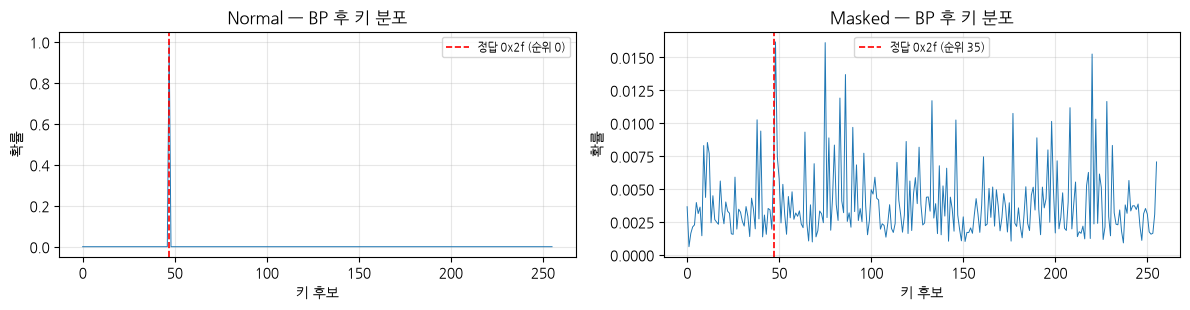

In [4]:
fig, axes = plt.subplots(1, len(dists), figsize=(6.0 * len(dists), 3.2))
if len(dists) == 1:
    axes = [axes]
for ax, tid in zip(axes, dists):
    rank, dist = dists[tid]
    ax.plot(dist, lw=0.7)
    ax.axvline(TRUE_KEY[BYTE], color="r", ls="--", lw=1.2,
               label="정답 0x%02x (순위 %d)" % (TRUE_KEY[BYTE], rank))
    ax.set_title("%s — BP 후 키 분포" % TARGETS[tid]["short"])
    ax.set_xlabel("키 후보"); ax.set_ylabel("확률")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
fig.tight_layout(); plt.show()

---
## 4. 트레이스 수와 반복 횟수의 영향

`it` 은 메시지를 몇 번 주고받을지다.

**믿음이 키에 닿으려면 몇 번이 필요한가?** 우리 그래프에서 증거는 `y` 에 붙는데,
`k` 까지 가려면 `y → x`(sbox 제약)와 `x → k`(xor 제약) **두 홉**을 지나야 한다.
그래서 `it=1` 로는 `k` 의 분포가 아직 만들어지지 않는다.

> **이때 SCALib 은 예외를 던지지 않고 `get_distribution()` 이 `None` 을 돌려준다.**
> 모르고 쓰면 `TypeError: bad operand type for unary -: 'NoneType'` 같은 엉뚱한 곳에서
> 터진다. 반환값을 항상 확인한다.

이 그래프는 사이클이 없으므로(`bp.is_cyclic()` 이 `False`) 몇 번이면 수렴하고,
`bp_acyclic("k")` 로 정확한 답을 한 번에 구할 수도 있다.
루프가 있는 큰 그래프에서는 수렴이 보장되지 않아 `it` 이 실제로 중요해진다.

In [5]:
STEPS = [1, 2, 3, 5, 10, 20, 30]
print("%-8s " % "타겟" + " ".join("%6d장" % s for s in STEPS))
for tid in sets:
    rr = [sasca_rank(tid, n_atk=min(s, proba_map[tid].shape[0]))[0] for s in STEPS]
    print("%-8s " % TARGETS[tid]["short"]
          + " ".join("%7s" % ("-" if r is None else r) for r in rr))

print()
fg = FactorGraph(GRAPH, {"sbox": SBOX.astype(np.uint32)})
print("그래프에 사이클이 있는가:",
      BPState(fg, 1, {"p": np.zeros(1, dtype=np.uint32)}).is_cyclic())
print()
print("%-8s %6s %14s" % ("타겟", "it", "키 순위"))
for tid in sets:
    for it in (1, 2, 5, 20):
        r = sasca_rank(tid, it=it)[0]
        print("%-8s %6d %14s" % (TARGETS[tid]["short"], it,
                                 "미도달 (None)" if r is None else r))
    print()
print("it=1 은 y 에서 k 까지 두 홉을 못 건너 분포가 없다.")
print("it>=2 부터 값이 나오고, 사이클이 없으므로 그 뒤로는 더 돌려도 같다.")

타겟            1장      2장      3장      5장     10장     20장     30장
Normal         8       2       0       0       0       0       0
Masked       248     250      99     193     229      32      35

그래프에 사이클이 있는가: False

타겟           it           키 순위
Normal        1     미도달 (None)
Normal        2              0
Normal        5              0
Normal       20              0

Masked        1     미도달 (None)
Masked        2             35
Masked        5             35
Masked       20             35

it=1 은 y 에서 k 까지 두 홉을 못 건너 분포가 없다.
it>=2 부터 값이 나오고, 사이클이 없으므로 그 뒤로는 더 돌려도 같다.


---
## 5. 요약

| 항목 | 내용 |
|------|------|
| 목적 | 여러 중간값의 확률을 **그래프로 합쳐** 키 분포를 얻는다 |
| API | `FactorGraph(desc, tables)` → `BPState(fg, n, pub)` → `set_evidence` → `bp_loopy` → `get_distribution` |
| 문법 | `NC` / `TABLE` / `VAR SINGLE` / `VAR MULTI` / `PUB MULTI` / `PROPERTY` |
| dtype | 테이블·`PUB` 는 `uint32`, 증거는 `float64` 이고 **행합 1** |
| 전제 | 증거의 품질이 결과를 결정한다. SASCA 는 정보를 **만들지 않는다** |

### 이 데이터셋에서 관측한 것

Normal 은 파형 몇 장의 증거만으로 키 바이트가 1등에 온다.
Masked 는 같은 그래프·같은 절차를 써도 1등에 이르지 못한다. 증거(4.0 의 LDA 확률)가
Normal 만큼 날카롭지 않기 때문이며, **그래프를 아무리 잘 짜도 이 격차는 메워지지 않는다.**

**대책 평가 관점에서 중요한 함의:** 공격 기법을 정교하게 만드는 것만으로는
마스킹을 넘지 못한다. 넘으려면 **다른 중간값**(고차 조합, 마스크 자체)을 겨눠야 하고,
그 비용은 2.1 에서 본 대로 급격히 커진다.

### 실패 시 점검

1. `set_evidence` 의 확률이 정규화되지 않으면 결과가 이상해진다.
2. 테이블·`PUB` 의 dtype 이 `uint32` 가 아니면 예외가 난다.
3. `initialize_states=True` 를 빠뜨리면 이전 실행 상태가 섞인다.
4. `get_distribution()` 이 `None` 이면 예외가 아니라 **`it` 이 모자란 것**이다.
   증거에서 그 변수까지의 홉 수 이상으로 늘린다.
5. 순위가 안 좋다 → 그래프가 아니라 **증거(LDA)** 를 먼저 의심한다. 4.0 으로 돌아간다.

다음: `6.0.KeyRank.ipynb` — 16바이트를 합쳐 128비트 키 전체의 순위를 센다.